In [1]:
from O.interface import *
DIR_main = "/Users/matteo/Projects/NF_PGMmol/butane"

I0000 00:00:1781156267.851924  893368 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1781156267.852060  893368 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires

# Environment Setup and Runtime Management

This section imports the Python modules required for handling atomistic simulation data, post-processing i-PI trajectories, plotting results, and managing long-running calculations.

## Atomic Structures and Trajectories

The script uses the Atomic Simulation Environment (ASE) to read, manipulate, and write atomic structures and trajectories:

```python
from ase.io import read, write
from ase import Atoms
from ase.io import Trajectory
```

These modules provide functionality for loading structures from common file formats, creating and modifying atomic configurations, and storing trajectories generated during molecular dynamics simulations.

## i-PI Utilities

```python
from ipi import read_output
from ipi import read_trajectory
```

These functions are used to parse output files and trajectories generated by i-PI simulations, enabling efficient extraction of thermodynamic observables and atomic configurations for subsequent analysis.

## Physical Constants

```python
from ase.units import _k, Bohr, _e, Hartree, J
```

Several physical constants and unit conversion factors are imported from ASE, including the Boltzmann constant, the Bohr radius, the elementary charge, the Hartree energy, and the Joule. These are useful when converting quantities between different unit systems commonly encountered in atomistic simulations.

## Auxiliary Modules

```python
import shutil
import matplotlib.pyplot as plt
import signal
import time
import os
```

These libraries provide functionality for file management, data visualization, signal handling, runtime monitoring, and interaction with the operating system.

## TensorFlow GPU Memory Management

```python
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
```

This environment variable instructs TensorFlow to allocate GPU memory dynamically as required, rather than reserving all available GPU memory at startup. This can improve compatibility when multiple processes share the same GPU resources.

## Runtime Control

To prevent jobs from exceeding scheduler-imposed wall-time limits, the script defines a simple runtime monitoring mechanism:

```python
JOB_TIME_LIMIT = 36 * 60 * 60
SAFETY_MARGIN = 20 * 60
START_TIME = time.time()
```

Here, `JOB_TIME_LIMIT` specifies the maximum allowed runtime (36 hours), while `SAFETY_MARGIN` reserves the final 20 minutes for a clean shutdown and data writing. The start time of the calculation is recorded when the script is launched.

### Remaining Time

```python
def time_remaining():
    """Returns time remaining before safety cutoff (in seconds)"""
    elapsed = time.time() - START_TIME
    return JOB_TIME_LIMIT - SAFETY_MARGIN - elapsed
```

This function computes the amount of time remaining before the safety threshold is reached.

### Timeout Protection

```python
def check_timeout():
    """Raises TimeoutError if we're approaching the time limit"""
    if time_remaining() <= 0:
        raise TimeoutError("Approaching job time limit - stopping early")
```

This function can be called periodically during long calculations. If the remaining runtime falls below the safety threshold, a `TimeoutError` is raised, allowing the workflow to terminate gracefully before the scheduler forcibly kills the job.


In [2]:
from ase.io import read, write
from ase import Atoms
from ase.io import Trajectory
import chemiscope
import shutil
from ipi import read_output
from ipi import read_trajectory
from ase.units import _k, Bohr, _e, Hartree, J
import matplotlib.pyplot as plt
import signal
import time
import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true' 

JOB_TIME_LIMIT = 36 * 60 * 60  # 24 hours
SAFETY_MARGIN = 20 * 60  # Stop 10 minutes early
START_TIME = time.time()

def time_remaining():
    """Returns time remaining before safety cutoff (in seconds)"""
    elapsed = time.time() - START_TIME
    return JOB_TIME_LIMIT - SAFETY_MARGIN - elapsed

def check_timeout():
    """Raises TimeoutError if we're approaching the time limit"""
    if time_remaining() <= 0:
        raise TimeoutError("Approaching job time limit - stopping early") 


## Loading and Visualizing the Butane Trajectory

The butane molecular dynamics trajectory is loaded and visualized using ASE, i-PI utilities, and Chemiscope. First, the simulation output is read from the i-PI output file:

```python
data, info = read_output(name + "/restrained_4.out")
```

which extracts the thermodynamic observables recorded during the simulation (e.g., temperature, energy, and simulation time). The atomic configurations are then loaded from the ASE trajectory file:

```python
atoms_traj = read("./butane/restrained_anti_100ps.traj", index=":")
```

where `index=":"` instructs ASE to read all frames in the trajectory. The resulting `atoms_traj` object is a list of ASE `Atoms` objects representing the molecular configurations sampled over the course of the 100 ps simulation.

To facilitate interactive inspection of the conformational dynamics, the trajectory is visualized within the notebook using Chemiscope:

```python
chemiscope.show(
    frames=atoms_traj,
    mode="structure",
)
```

This provides an interactive molecular viewer that allows the trajectory to be explored frame by frame, enabling direct observation of structural fluctuations and conformational transitions sampled during the simulation.


In [24]:
name='butane_TS'

single_mol_pdb = f'./{name}/seed_anti.pdb'

# trajectory file
file = f"./{name}/restrained_barrier1_100ps.traj"

# read all ASE frames
atoms_traj = read(file, index=":")

# launch chemiscope viewer in the notebook
chemiscope.show(
    frames=atoms_traj,
    mode="structure",
)

/var/folders/1_/5wbhw9_91r1ftt9zpxkr13ww0000gn/T/ipykernel_33970/654614237.py:12: UserWarning: `frames` argument is deprecated, use `structures` instead
  chemiscope.show(


<StructureWidget(meta={'name': ' '}, structures=[{'size': 14, 'data': 'structure-0'}, {'size': 14, 'data': 'st…

## Computing Potential Energies with MACE-OFF

To evaluate the potential energy along the trajectory, each frame is processed using the MACE-OFF medium foundation model operating in double precision (`float64`). To avoid unnecessary recomputation, the workflow first checks whether a file containing previously computed energies already exists. If so, the energies are loaded directly from disk; otherwise, they are evaluated using the machine-learning potential and subsequently saved for future use.

The MACE calculator is initialized as:

```python
calc = mace_off(
    model="medium",
    device="cpu",
    default_dtype="float64"
)
```

Each structure in the trajectory is then assigned this calculator and its potential energy is evaluated in electronvolts (eV). The resulting energy values are stored in a NumPy array and written to a text file:

```python
maceoff_medium_float64_energies.dat
```

for reuse in subsequent analyses. A progress bar (`tqdm`) is employed to monitor the calculation when processing large trajectories.

Finally, basic statistics of the energy distribution are reported, including the total number of frames, the mean potential energy, and its standard deviation. This provides a convenient summary of the energetic fluctuations sampled during the molecular dynamics simulation.


In [4]:
import os
import numpy as np
from mace.calculators import mace_off
from tqdm.auto import tqdm

energy_file = f"{name}/maceoff_medium_float64_energies.dat"

if os.path.exists(energy_file):

    print(f"Loading existing energies from {energy_file}")
    pot_energy = np.loadtxt(energy_file)

else:

    print("Energy file not found. Computing energies...")

    calc = mace_off(
        model="medium",
        device="cpu",          # use "mps" on Apple Silicon if desired
        default_dtype="float64"
    )

    energies = []

    for atoms in tqdm(atoms_traj):
        atoms.calc = calc
        energies.append(atoms.get_potential_energy())  # eV

    pot_energy = np.array(energies)

    np.savetxt(
        energy_file,
        energies,
        header="Potential energy / eV"
    )

    print(f"Saved energies to {energy_file}")

print(f"Number of frames: {len(pot_energy)}")
print(f"Mean energy: {pot_energy.mean():.8f} eV")
print(f"Std energy:  {pot_energy.std():.8f} eV")


/Users/matteo/miniforge3/envs/FEcrys_metal/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Loading existing energies from butane_TS/maceoff_medium_float64_energies.dat
Number of frames: 1001
Mean energy: -4313.71161485 eV
Std energy:  0.13766822 eV


In [5]:
import numpy as np
from ase import Atoms
from ase.io import write, read
from mace.calculators import mace_off

# discard initial equilibration frames
start = 0
T = 300.0

# eV -> kT
eV_to_kT = 1.602176634e-19 / (1.380649e-23 * T)
print("eV_to_kT:", eV_to_kT)

# ASE positions are Å; interface expects nm
r = np.array(
    [atoms.get_positions() for atoms in atoms_traj[start:]],
    dtype=np.float32
) / 10.0

# ASE cells are Å; interface expects nm
b_all = np.array(
    [atoms.get_cell().array for atoms in atoms_traj[start:]],
    dtype=np.float32
) / 10.0

# Use the first cell as b0
b0 = b_all[0].astype(np.float32)

# Energies from MACE are eV; interface expects kT
u = np.array(pot_energy[start:], dtype=np.float64).reshape(-1, 1) * eV_to_kT

assert len(r) == len(u)

chem_symbols = atoms_traj[start].get_chemical_symbols()

# Write single-molecule PDB; ASE expects Å
single_atom_pos = Atoms(
    chem_symbols,
    positions=r[0] * 10.0,      # nm -> Å
    cell=np.diag([25.0, 25.0, 25.0]),
    pbc=True
)

write(single_mol_pdb, single_atom_pos)

atoms_single_mol = read(single_mol_pdb)
n_atoms_mol = len(atoms_single_mol)

calculator = mace_off(
    model="medium",
    device="cpu",
    default_dtype="float64"
)

def u_calc(rs, b=b0):
    """
    rs is expected in nm.
    Returns energy in kT, shape (n_frames, 1).
    """
    atoms_list = [
        Atoms(
            chem_symbols,
            positions=rs[i] * 10.0,   # nm -> Å
            pbc=False
        )
        for i in range(len(rs))
    ]

    pot_energies = []
    for atoms in atoms_list:
        atoms.calc = calculator
        pot_energies.append(atoms.get_potential_energy() * eV_to_kT)

    return np.array(pot_energies).reshape(-1, 1)

print("r shape:", r.shape, "units: nm")
print("b0 shape:", b0.shape, "units: nm")
print("u shape:", u.shape, "units: kT")
print("u range / kT:", float(u.min()), float(u.max()))



eV_to_kT: 38.681727071833606
Using MACE-OFF23 MODEL for MACECalculator with /Users/matteo/.cache/mace/MACE-OFF23_medium.model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
r shape: (1001, 14, 3) units: nm
b0 shape: (3, 3) units: nm
u shape: (1001, 1) units: kT
u range / kT: -166875.8489394564 -166843.4381571867


/Users/matteo/miniforge3/envs/FEcrys_metal/lib/python3.12/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


### `NN_interface_sc_multimap_selective_evaluation_(...)`

This call creates and initializes a neural-network interface for learning the equilibrium configurational distribution of a molecular system from molecular dynamics data.

The object acts as a container that stores the molecular configurations, energies, coordinate transformations, and training settings required for subsequent normalizing-flow training.

Key inputs are:

1. **Molecular configurations**
   ```python
   list_r = [r]
   ```

Cartesian coordinates sampled from molecular dynamics. Each configuration has shape `(N_atoms, 3)` and the dataset has shape `(N_frames, N_atoms, 3)`.

2. **Simulation box**

   ```python
   list_b0 = [b]
   ```

   Reference simulation cell associated with the trajectory.

3. **Potential energies**

   ```python
   list_u = [u.reshape([-1,1])]
   ```

   Potential energies corresponding to each sampled configuration.

4. **Potential-energy function**

   ```python
   list_u_ = [u_calc]
   ```

   Callable function that evaluates the energy of arbitrary molecular configurations. This is used during free-energy estimation and model validation.

5. **Molecular topology**

   ```python
   single_mol_pdb_file = single_mol_pdb
   ```

   PDB file describing the molecular connectivity and atom ordering used to construct internal coordinates.

6. **Training mode**

   ```python
   training = True
   ```

   Indicates that the supplied trajectory data will be used to train a generative model.

7. **Training/validation split**

   ```python
   fraction_training = 0.8
   ```

   Uses 80% of the configurations for training and 20% for validation.

8. **Coordinate representation**

   ```python
   ic_map_class = SingleMolecule_map
   ```

   Specifies the coordinate transformation used to convert Cartesian molecular structures into an internal-coordinate representation.

9. **Generative model architecture**

   ```python
   model_class = PGMmol
   ```

   Specifies the normalizing-flow model used to learn the equilibrium probability distribution.

10. **Number of thermodynamic states**

    ```python
    n_states = 1
    ```

    Indicates that a single molecular ensemble is being modelled. The same interface can also be used for multiple thermodynamic states or polymorphs.

The resulting object (`nn`) contains all information required for the subsequent workflow:

```python
nn.set_ic_map_step1(...)
nn.set_ic_map_step2(...)
nn.set_ic_map_step3(...)
nn.set_model(...)
nn.set_trainer(...)
nn.train(...)
```

which progressively constructs the internal-coordinate map, initializes the normalizing flow, and trains a probabilistic model of the molecular configurational ensemble.



In [6]:
nn = NN_interface_sc_multimap_selective_evaluation_( 
                                                    
                                                    name = 'butane_maceoff_medium',
                                                    n_states = 1,

                                                    list_r  = [r],
                                                    list_b0 = [b0],
                                                    list_u  = [u.reshape([-1, 1])],
                                                    list_u_ = [u_calc],
                                                    single_mol_pdb_file = single_mol_pdb,

                                                    training = True,

                                                    fraction_training =  0.5,
                                                    running_in_notebook = True,
                                                    model_class = PGMmol,
                                                    ic_map_class = SingleMolecule_map

                                                    
                                )

_nn = nn.nns[0]

# assign callable PES function
_nn.u_ = u_calc

_nn.u_mean = _nn.u.mean()
_nn.n_training = int(_nn.u.shape[0] * _nn.fraction_training)

print(type(_nn.u), _nn.u.shape)
print(type(_nn.u_), callable(_nn.u_))

print(type(u_calc))
print(callable(u_calc))


<class 'numpy.ndarray'> (1001, 1)
<class 'function'> True
<class 'function'>
True


### `nn.set_ic_map_step1(ind_root_atom=0, option=None)`

This step defines how molecular configurations will be converted from Cartesian coordinates into an internal-coordinate representation.

It performs two operations:

1. **Load the molecular topology**
   ```python
   self.ic_map = self.ic_map_class(PDB_single_mol=PDBmol)

A single-molecule PDB file is used to identify the molecular connectivity and atom ordering.

2. **Define the internal-coordinate reference frame**

   ```python
   self.ic_map.set_ABCD_(
       ind_root_atom=ind_root_atom,
       option=option
   )
   ```

   A root atom (`A`) and associated reference atoms (`B`, `C`, `D`) are selected to establish a unique molecular frame. These atoms define the orientation conventions used when constructing bond lengths, bond angles, torsions, and rotational coordinates.

The choice of `ind_root_atom` and `option` determines the internal-coordinate mapping and should remain fixed for a given molecular species to ensure consistency across datasets and trained models.

This step does **not** modify the MD data. It only defines the coordinate system that will later be used to transform configurations into internal coordinates during `set_ic_map_step3()`.


In [7]:
nn.set_ic_map_step1(ind_root_atom = 1, option = None)

molecule with 14 atoms, of which 4 are heavy atoms, and the rest are 10 hydrogens.
atoms with incides [1, 8, 0] are set to be the Cartesian_Block
position of the molecule specified by atoms with index: 1
rotation of the molecule specified by atoms with indices: [8, 0]
conformation of the molecule specified by all other atoms.


In [8]:
print(_nn.ic_map.ABCD)

{0: [8], 1: [1, 8], 2: [0, 1, 8], 3: [4, 0, 1, 8], 4: [5, 0, 1, 8], 5: [6, 0, 1, 8], 6: [2, 1, 0, 4], 7: [3, 2, 1, 8], 8: [11, 3, 2, 1], 9: [12, 3, 2, 1], 10: [13, 3, 2, 1], 11: [9, 2, 1, 8], 12: [10, 2, 1, 8], 13: [7, 1, 0, 4]}


In [9]:
def plot_mol_larger_(mol,save_path = None):
    mol.RemoveConformer(0)
    from rdkit.Chem import Draw
    from IPython.display import Image, display
    img = Draw.MolToImage(mol, size=(800, 800)) # Specify size here
    if save_path:
        img.save(f'{name}' + save_path)
    else:
        display(img)

plot_mol_larger_(_nn.ic_map.mol, save_path = 'molecule.png')


### `nn.set_ic_map_step2()`

This step prepares the molecular dynamics dataset before constructing the internal-coordinate map.

It performs three operations:

1. **Remove centre-of-mass motion**
   ```python
   self.r = self.ic_map.remove_COM_from_data_(self.r)

All configurations are translated so that the centre of mass is fixed at the origin, removing trivial translational degrees of freedom.

2. **Create training and validation sets**

   ```python
   self.set_training_validation_split_(...)
   ```

   The MD configurations and corresponding energies are divided into training and validation subsets using an energy-balanced random split.

3. **Verify PES consistency (optional)**

   ```python
   self.check_PES_matching_dataset_()
   ```

   The potential-energy function is re-evaluated on a subset of configurations and compared against the stored MD energies to ensure the dataset is consistent with the force field.

This step does **not** construct internal coordinates yet; it simply preprocesses the dataset for the subsequent initialization of the coordinate map in `set_ic_map_step3()`.



In [10]:
# discard initial equilibration frames
start = 0
T = 300.0

# eV -> kT
eV_to_kT = 1.602176634e-19 / (1.380649e-23 * T)
print("eV_to_kT:", eV_to_kT)

# ASE positions are Å; interface expects nm
r = np.array(
    [atoms.get_positions() for atoms in atoms_traj[start:]],
    dtype=np.float32
) / 10.0

# ASE cells are Å; interface expects nm
b_all = np.array(
    [atoms.get_cell().array for atoms in atoms_traj[start:]],
    dtype=np.float32
) / 10.0

# Use the first cell as b0
b0 = b_all[0].astype(np.float32)

# Energies from MACE are eV; interface expects kT
u = np.array(pot_energy[start:], dtype=np.float64).reshape(-1, 1) * eV_to_kT

assert len(r) == len(u)

chem_symbols = atoms_traj[start].get_chemical_symbols()

# Write single-molecule PDB; ASE expects Å
single_atom_pos = Atoms(
    chem_symbols,
    positions=r[0] * 10.0,      # nm -> Å
    cell=np.diag([25.0, 25.0, 25.0]),
    pbc=True
)

write(single_mol_pdb, single_atom_pos)

atoms_single_mol = read(single_mol_pdb)
n_atoms_mol = len(atoms_single_mol)

calculator = mace_off(
    model="medium",
    device="cpu",
    default_dtype="float64"
)

def u_calc(rs, b=b0):
    """
    rs is expected in nm.
    Returns energy in kT, shape (n_frames, 1).
    """
    atoms_list = [
        Atoms(
            chem_symbols,
            positions=rs[i] * 10.0,   # nm -> Å
            pbc=False
        )
        for i in range(len(rs))
    ]

    pot_energies = []
    for atoms in atoms_list:
        atoms.calc = calculator
        pot_energies.append(atoms.get_potential_energy() * eV_to_kT)

    return np.array(pot_energies).reshape(-1, 1)

print("r shape:", r.shape, "units: nm")
print("b0 shape:", b0.shape, "units: nm")
print("u shape:", u.shape, "units: kT")
print("u range / kT:", float(u.min()), float(u.max()))

eV_to_kT: 38.681727071833606
Using MACE-OFF23 MODEL for MACECalculator with /Users/matteo/.cache/mace/MACE-OFF23_medium.model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
r shape: (1001, 14, 3) units: nm
b0 shape: (3, 3) units: nm
u shape: (1001, 1) units: kT
u range / kT: -166875.8489394564 -166843.4381571867


/Users/matteo/miniforge3/envs/FEcrys_metal/lib/python3.12/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


stored u range / kT: -166872.92224795607 -166846.66576543747
recalc u range / kT: -166872.92224949854 -166846.6657813075

u_calc(r) - u / kT
mean: 3.2309195376001297e-07
std : 1.6963836813498327e-05
min : -4.8259622417390347e-05
max : 5.091182538308203e-05
MAE : 1.326478479313664e-05
RMSE: 1.6966913326989846e-05


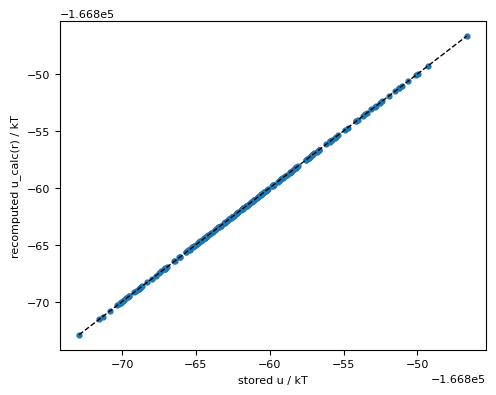

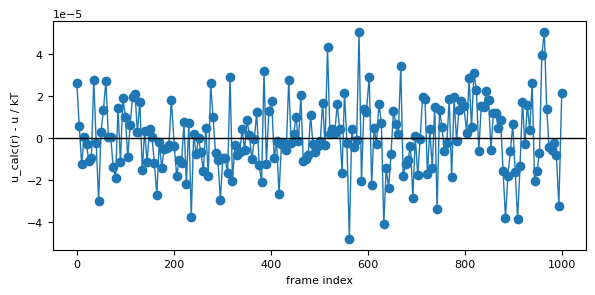

In [11]:
n_check = min(200, len(r))
inds = np.linspace(0, len(r) - 1, n_check, dtype=int)

u_stored = u[inds].reshape(-1, 1)
u_recalc = u_calc(r[inds]).reshape(-1, 1)

du = u_recalc - u_stored

print("stored u range / kT:", float(u_stored.min()), float(u_stored.max()))
print("recalc u range / kT:", float(u_recalc.min()), float(u_recalc.max()))

print()
print("u_calc(r) - u / kT")
print("mean:", float(du.mean()))
print("std :", float(du.std()))
print("min :", float(du.min()))
print("max :", float(du.max()))
print("MAE :", float(np.mean(np.abs(du))))
print("RMSE:", float(np.sqrt(np.mean(du**2))))

plt.figure(figsize=(5, 4))
plt.scatter(u_stored, u_recalc, s=12)
lo = min(float(u_stored.min()), float(u_recalc.min()))
hi = max(float(u_stored.max()), float(u_recalc.max()))
plt.plot([lo, hi], [lo, hi], "k--", lw=1)
plt.xlabel("stored u / kT")
plt.ylabel("recomputed u_calc(r) / kT")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(inds, du[:, 0], marker="o", lw=1)
plt.axhline(0, color="k", lw=1)
plt.xlabel("frame index")
plt.ylabel("u_calc(r) - u / kT")
plt.tight_layout()
plt.show()




In [12]:
_nn = nn.nns[0]
ic = _nn.ic_map

# Optional geometry sanity check before COM removal
r_check = _nn.r

for atom, refs in ic.ABCD.items():
    if len(refs) >= 2:
        i, j = refs[0], refs[1]
        d = np.linalg.norm(r_check[:, i, :] - r_check[:, j, :], axis=1)
        print(atom, (i, j), d.min(), d.mean(), d.max())

# Now run the usual preprocessing.
# Keep check_PES=True now: it should pass if u and u_calc are consistent.
nn.set_ic_map_step2(check_PES=True)

nn.set_ic_map_step3(n_mol_unitcells=1)




1 (1, 8) 0.09981983 0.10946154 0.12015692
2 (0, 1) 0.14489552 0.15340221 0.16744088
3 (4, 0) 0.099989094 0.10968237 0.12088879
4 (5, 0) 0.100744806 0.10954486 0.12403633
5 (6, 0) 0.09936074 0.1095763 0.121227026
6 (2, 1) 0.14577037 0.1546852 0.16732241
7 (3, 2) 0.14395145 0.15321977 0.16431881
8 (11, 3) 0.09882543 0.10943189 0.11888212
9 (12, 3) 0.10023619 0.109468155 0.12009121
10 (13, 3) 0.09931538 0.109342985 0.12132408
11 (9, 2) 0.100625135 0.10956882 0.121655636
12 (10, 2) 0.100262694 0.10945585 0.12042647
13 (7, 1) 0.09842735 0.10952279 0.11939103
COM removed from data without taking into account PBC of the box
inds_rand attempt: 1
! not found
inds_rand attempt: 2
found !
checking that PES matches the sampled dataset:
errT: -7.048034967738204e-07 -6.023267633281648e-05 5.468053859658539e-05
errV: -2.2162385898832213e-06 -5.5790558690205216e-05 5.71858836337924e-05
initialising on 1001 datapoints provided
5 out of 11 potentially periodic marginal variables are set to periodic
This

In [13]:
nn.set_model(n_layers = 2, learning_rate=0.001, n_att_heads=1, evaluation_batch_size=400)

There are 919044 trainable parameters in this model, among 32 trainable weights.
[To see dimensionalities of the trainable weights print(list(self.shapes_trainable_weights)).] 


<unknown>:754: SyntaxWarning: invalid escape sequence '\i'
<unknown>:754: SyntaxWarning: invalid escape sequence '\i'
<unknown>:754: SyntaxWarning: invalid escape sequence '\i'
<unknown>:582: SyntaxWarning: invalid escape sequence '\p'
<unknown>:582: SyntaxWarning: invalid escape sequence '\p'


inv_test_res0 ([[np.float32(0.13566941), np.float32(0.6553986)], [np.float32(7.2118655e-06), np.float32(0.0), np.float32(3.0517578e-05)]], [[[np.float32(5.0407505e-07), np.float32(4.7683716e-06)]], [np.float32(5.3899207e-06), np.float32(-5.340576e-05), np.float32(5.340576e-05)]])


In [14]:
nn.set_trainer(n_batches_between_evaluations=4)

'0.45 79 82 20 AVMD_T:[-166728.07748441] AVMD_V:[np.float64(-166742.47712348396)] || FE:[np.float64(0.0)] SD:[np.float64(0.0)]'

In [15]:
for k, _nn in enumerate(nn.nns):
    print(k, _nn.r_training.shape, _nn.r_validation.shape)

min_train = min(len(_nn.r_training) for _nn in nn.nns)
print("min training frames:", min_train)


0 (800, 14, 3) (201, 14, 3)
min training frames: 800


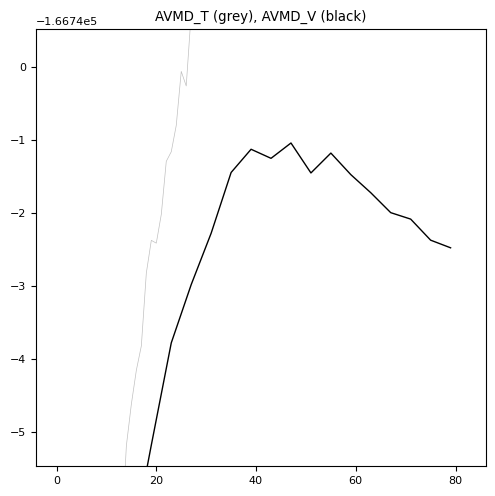

training time so far: 0.45 minutes
saved /Users/matteo/Projects/NF_PGMmol/butane_TS/NN/training_results/misc/butane_maceoff_medium_SC__misc_
misc training outputs were saved
AttributeError("Can't get local object 'Layer._initialize_tracker.<locals>.<lambda>'") failed to save full model; saving weights only instead
weights saved to: /Users/matteo/Projects/NF_PGMmol/butane_TS/NN/training_results/fitted_models/butane_maceoff_medium_SC__weights_np.npz
metadata saved to: /Users/matteo/Projects/NF_PGMmol/butane_TS/NN/training_results/fitted_models/butane_maceoff_medium_SC__metadata.pkl


In [17]:
from pathlib import Path

# --- 1. Make output folders robust ---
DIR_main_fixed = Path("/Users/matteo/Projects/NF_PGMmol/butane_TS").resolve()

dirs = {
    "dir_results_BAR":     DIR_main_fixed / "NN/training_results/BAR",
    "dir_results_misc":    DIR_main_fixed / "NN/training_results/misc",
    "dir_results_samples": DIR_main_fixed / "NN/training_results/samples",
    "dir_results_models":  DIR_main_fixed / "NN/training_results/fitted_models",
    "path_to_misc":        DIR_main_fixed / "NN/training_results/misc"
}

for obj in [nn] + list(nn.nns):
    for attr, path in dirs.items():
        path.mkdir(parents=True, exist_ok=True)
        setattr(obj, attr, str(path) + "/")

print("BAR save prefix:  ", nn.name_save_BAR_inputs)
print("Model save prefix:", nn.name_save_model)

# --- 2. Use safe batch sizes ---
min_train = min(len(_nn.r_training) for _nn in nn.nns)
min_valid = min(len(_nn.r_validation) for _nn in nn.nns)

safe_training_batch_size = min(1000, min_train)
safe_evaluation_batch_size = min(5000, min_train, min_valid)

# If the model already exists, patch the stored evaluation batch size
nn.evaluation_batch_size = safe_evaluation_batch_size

print("min_train:", min_train)
print("min_valid:", min_valid)
print("training_batch_size:", safe_training_batch_size)
print("evaluation_batch_size:", safe_evaluation_batch_size)

# --- 3. Train ---
nn.train(
    n_batches=80,
    training_batch_size=safe_training_batch_size,
    f_halfwindow_visualisation=[3, 1.]
)

# --- 4. Save model ---
try:
    Path(nn.dir_results_models).mkdir(parents=True, exist_ok=True)
    nn.save_model_()
except Exception as e:
    print(repr(e), "failed to save full model; saving weights only instead")

    from pathlib import Path
    import numpy as np
    import pickle

    save_dir = Path(nn.dir_results_models)
    save_dir.mkdir(parents=True, exist_ok=True)

    weights_path = save_dir / f"{nn.name}_weights_np.npz"
    meta_path    = save_dir / f"{nn.name}_metadata.pkl"

    weights = list(nn.model.trainable_weights)

    np.savez_compressed(
        weights_path,
        **{f"arr_{i}": w.numpy() for i, w in enumerate(weights)}
    )

    metadata = {
        "name": nn.name,
        "n_crystals": nn.n_crystals,
        "evaluation_batch_size": nn.evaluation_batch_size,
        "n_weights": len(weights),
        "weight_shapes": [tuple(w.shape) for w in weights],
    }

    with open(meta_path, "wb") as f:
        pickle.dump(metadata, f)

    print("weights saved to:", weights_path)
    print("metadata saved to:", meta_path)



In [ ]:
import numpy as np

crystal_index = 0
_nn = nn.nns[crystal_index]

# If estimates are not currently loaded, load saved misc outputs
if not hasattr(_nn, "estimates"):
    nn.load_misc_()

AVMD_V = np.asarray(_nn.estimates[0, :, 1], dtype=float)

# Remove failed / dummy entries, if any
valid = np.isfinite(AVMD_V) & (AVMD_V > -1e19)

idx_valid = np.where(valid)[0]
idx_max = idx_valid[np.argmax(AVMD_V[valid])]

AVMD_V_max = AVMD_V[idx_max]

print("Maximum AVMD_V:", AVMD_V_max)
print("Index in estimates array:", idx_max)

if hasattr(_nn, "evaluation_grid"):
    print("Training batch:", _nn.evaluation_grid[idx_max])

Maximum AVMD_V: -166740.72148067004
Index in estimates array: 11
Training batch: 47


Best AVMD_V batches:
estimate index: 11 training batch: 47 AVMD_V: -166740.72148067004
estimate index: 12 training batch: 51 AVMD_V: -166740.85459261428
estimate index: 9 training batch: 39 AVMD_V: -166740.8761441735
estimate index: 13 training batch: 55 AVMD_V: -166741.1422943871
estimate index: 10 training batch: 43 AVMD_V: -166741.2857372907
estimate index: 15 training batch: 63 AVMD_V: -166741.35108518045
estimate index: 14 training batch: 59 AVMD_V: -166741.49586478432
estimate index: 16 training batch: 67 AVMD_V: -166741.557137135
estimate index: 8 training batch: 35 AVMD_V: -166741.6710126807
estimate index: 19 training batch: 79 AVMD_V: -166741.7733359566
found saved BAR result
rerun = True

two-state BAR evaluation in macrostate 0:
saved /Users/matteo/Projects/NF_PGMmol/butane_TS/NN/training_results/BAR/butane_maceoff_medium_SC__BAR__BAR_output_crystal_index=0
saved BAR result

Reweighted FE / kT: -166733.65353615102
Reweighted SE / kT: 0.3334384899121034
     grid search esti

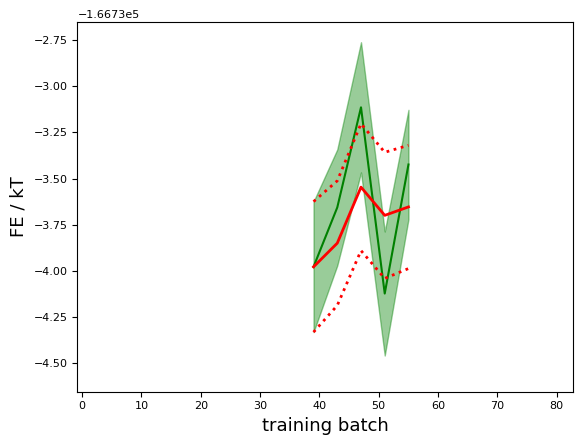

In [ ]:
import numpy as np
from pathlib import Path

# make sure outputs exist
for path in [
    nn.dir_results_BAR,
    nn.dir_results_misc,
    nn.dir_results_samples,
    nn.dir_results_models,
]:
    Path(path).mkdir(parents=True, exist_ok=True)

# load misc if coming back to an already trained model
if not hasattr(nn.nns[0], "estimates"):
    nn.load_misc_()

# show AVMD_V curve and chosen best points
_nn = nn.nns[0]
AVMD_V = np.asarray(_nn.estimates[0, :, 1], dtype=float)
valid = np.isfinite(AVMD_V) & (AVMD_V > -1e19)

idx_valid = np.where(valid)[0]
idx_sorted = idx_valid[np.argsort(AVMD_V[valid])[::-1]]

print("Best AVMD_V batches:")
for i in idx_sorted[:10]:
    print(
        "estimate index:", i,
        "training batch:", _nn.evaluation_grid[i],
        "AVMD_V:", AVMD_V[i]
    )

# selective reweighting
nn.solve_BAR_using_pymbar_(
    rerun=True,
    n_selective_evalautions=5
)

# result
print()
print("Reweighted FE / kT:", _nn.BAR_V_FE)
print("Reweighted SE / kT:", _nn.BAR_V_SE)

# plot
nn.plot_result_(
    crystal_index=0,
    window=1,
    n_mol=1
)

In [ ]:
import numpy as np

_nn = nn.nns[0]

# Stored MD energies, already in kT
u_MD = np.asarray(_nn.u).reshape(-1)

# Ensemble average potential energy from the sampled ensemble
U_mean_kT = np.mean(u_MD)
U_std_kT  = np.std(u_MD, ddof=1)
U_se_kT   = U_std_kT / np.sqrt(len(u_MD))

# Reweighted free energy from BAR, in kT
F_kT  = float(_nn.BAR_V_FE)
F_se_kT = float(_nn.BAR_V_SE)

# Entropic contribution: -T S = F - <U>
minus_TS_kT = F_kT - U_mean_kT

# Entropy in kB units: S/kB = U/kT - F/kT
S_over_kB = U_mean_kT - F_kT

print("Number of MD samples:", len(u_MD))
print()
print("<U> / kT        =", U_mean_kT, "+/-", U_se_kT)
print("F / kT          =", F_kT, "+/-", F_se_kT)
print("-T S / kT       =", minus_TS_kT)
print("S / kB          =", S_over_kB)

Number of MD samples: 1001

<U> / kT        = -166861.81535220443 +/- 0.16839901400190266
F / kT          = -166733.65353615102 +/- 0.3334384899121034
-T S / kT       = 128.16181605341262
S / kB          = -128.16181605341262


In [18]:
import numpy as np
from ase import Atoms
import chemiscope

# ============================================================
# User controls
# ============================================================

crystal_index = 0
n_structures_to_show = 200   # set None to show all generated structures
use_pbc = False              # True for periodic crystal/supercell
shift_energies = True        # nicer plotting in chemiscope

# ============================================================
# Load diagnostics if needed
# ============================================================

_nn = nn.nns[crystal_index]

if not hasattr(_nn, "estimates"):
    nn.load_misc_()

# ============================================================
# Find best model = maximum AVMD_V
# ============================================================

AVMD_V = np.asarray(_nn.estimates[0, :, 1], dtype=float)
valid = np.isfinite(AVMD_V) & (AVMD_V > -1e19)
idx_valid = np.where(valid)[0]

if len(idx_valid) == 0:
    raise RuntimeError("No valid AVMD_V entries found.")

idx_best = idx_valid[np.argmax(AVMD_V[valid])]

print("Best model according to max AVMD_V")
print("-----------------------------------")
print("estimate index :", idx_best)
print("training batch :", _nn.evaluation_grid[idx_best])
print("max AVMD_V     :", AVMD_V[idx_best])

# ============================================================
# Load generated samples from best model
# ============================================================

path_and_name = (
    _nn.name_save_BAR_inputs
    + "_BAR_input_"
    + str(idx_best)
    + "_state"
    + str(crystal_index)
    + "_"
)

name_samples = path_and_name + "_r_&_ln(q(r))"

print()
print("Loading generated samples from:")
print(name_samples)

r_BG, ln_q_BG, u_V, ln_q_V, w_V = load_pickle_(name_samples)

if n_structures_to_show is not None:
    r_BG = r_BG[:n_structures_to_show]
    ln_q_BG = ln_q_BG[:n_structures_to_show]

# ============================================================
# Compute generated-sample energies
# ============================================================

u_BG = _nn.u_(r_BG).reshape(-1)     # energies in kT
ln_q_BG = np.asarray(ln_q_BG).reshape(-1)

if shift_energies:
    u_ref = float(np.mean(u_BG))
    u_plot = u_BG - u_ref
    energy_name = "energy_minus_mean_kT"
    energy_desc = "Generated-sample energy minus mean energy, in kT"
else:
    u_ref = 0.0
    u_plot = u_BG
    energy_name = "energy_kT"
    energy_desc = "Generated-sample energy in kT"

print("Energy reference / kT:", u_ref)

# ============================================================
# Get atom symbols
# ============================================================

try:
    symbols = chem_symbols
except NameError:
    try:
        symbols = atoms_single_mol.get_chemical_symbols()
    except NameError:
        raise RuntimeError(
            "Could not find chem_symbols or atoms_single_mol. "
            "Define chem_symbols = atoms_traj[0].get_chemical_symbols()."
        )

# ============================================================
# Convert generated structures to ASE Atoms
# ============================================================

generated_atoms = []

for i, r_i in enumerate(r_BG):
    atoms = Atoms(
        symbols=symbols,
        positions=r_i * 10.0,   # nm -> Å
        pbc=use_pbc,
    )

    if use_pbc:
        atoms.cell = _nn.b0 * 10.0  # nm -> Å

    atoms.info["sample_index"] = i
    atoms.info["training_batch"] = int(_nn.evaluation_grid[idx_best])
    atoms.info["AVMD_V"] = float(AVMD_V[idx_best])
    atoms.info["ln_q"] = float(ln_q_BG[i])
    atoms.info["energy_kT"] = float(u_BG[i])
    atoms.info[energy_name] = float(u_plot[i])

    generated_atoms.append(atoms)

print("Number of generated structures shown:", len(generated_atoms))

# ============================================================
# Chemiscope properties and settings
# ============================================================

properties = {
    "sample_index": {
        "target": "structure",
        "values": np.arange(len(generated_atoms)),
    },
    "energy_kT": {
        "target": "structure",
        "values": u_BG,
    },
    energy_name: {
        "target": "structure",
        "values": u_plot,
    },
    "ln_q": {
        "target": "structure",
        "values": ln_q_BG,
    },
    "AVMD_V": {
        "target": "structure",
        "values": np.full(len(generated_atoms), AVMD_V[idx_best]),
    },
    "training_batch": {
        "target": "structure",
        "values": np.full(len(generated_atoms), _nn.evaluation_grid[idx_best]),
    },
}

settings = {
    "map": {
        "x": {"property": "sample_index"},
        "y": {"property": energy_name},
        "color": {"property": energy_name},
    },
    "structure": [
        {
            "bonds": True,
            "unitCell": use_pbc,
        }
    ],
}

# ============================================================
# Show in Chemiscope
# ============================================================

chemiscope.show(
    frames=generated_atoms,
    properties=properties,
    settings=settings,
    mode="default",
)

Best model according to max AVMD_V
-----------------------------------
estimate index : 11
training batch : 47
max AVMD_V     : -166741.03792516555

Loading generated samples from:
/Users/matteo/Projects/NF_PGMmol/butane_TS/NN/training_results/BAR/butane_maceoff_medium_SC__BAR__BAR_input_11_state0__r_&_ln(q(r))
Energy reference / kT: -165654.05325693014
Number of generated structures shown: 200


/var/folders/1_/5wbhw9_91r1ftt9zpxkr13ww0000gn/T/ipykernel_33970/2851543076.py:178: UserWarning: `frames` argument is deprecated, use `structures` instead
  chemiscope.show(


<ChemiscopeWidget(meta={'name': ' '}, settings={'map': {'x': {'property': 'sample_index'}, 'y': {'property': '…

In [19]:
import numpy as np
from ase import Atoms
import chemiscope

# ============================================================
# User controls
# ============================================================

crystal_index = 0
estimate_index = 0          # first saved batch
n_structures_to_show = 200  # set None to use all saved structures
use_pbc = False             # True for periodic crystal/supercell

# ============================================================
# Get the relevant NN object
# ============================================================

_nn = nn.nns[crystal_index]

# Load misc if needed
if not hasattr(_nn, "estimates"):
    nn.load_misc_()

# ============================================================
# Load generated samples from the first saved BAR batch
# ============================================================

path_and_name = (
    _nn.name_save_BAR_inputs
    + "_BAR_input_"
    + str(estimate_index)
    + "_state"
    + str(crystal_index)
    + "_"
)

name_samples = path_and_name + "_r_&_ln(q(r))"

print("Loading generated samples from:")
print(name_samples)

r_BG, ln_q_BG, u_V, ln_q_V, w_V = load_pickle_(name_samples)

print("Available generated structures:", len(r_BG))

if n_structures_to_show is not None:
    r_BG = r_BG[:n_structures_to_show]
    ln_q_BG = ln_q_BG[:n_structures_to_show]

# ============================================================
# Optional: compute energies of these generated structures
# ============================================================

u_BG = _nn.u_(r_BG).reshape(-1)
ln_q_BG = np.asarray(ln_q_BG).reshape(-1)

# ============================================================
# Get atomic symbols
# ============================================================

try:
    symbols = chem_symbols
except NameError:
    try:
        symbols = atoms_single_mol.get_chemical_symbols()
    except NameError:
        raise RuntimeError(
            "Could not find chem_symbols or atoms_single_mol. "
            "Define chem_symbols = atoms_traj[0].get_chemical_symbols()."
        )

# ============================================================
# Convert generated structures to ASE Atoms
# r_BG is in nm, ASE expects Å
# ============================================================

generated_atoms = []

for i, r_i in enumerate(r_BG):
    atoms = Atoms(
        symbols=symbols,
        positions=r_i * 10.0,   # nm -> Å
        pbc=use_pbc,
    )

    if use_pbc:
        atoms.cell = _nn.b0 * 10.0  # nm -> Å

    atoms.info["sample_index"] = i
    atoms.info["energy_kT"] = float(u_BG[i])
    atoms.info["ln_q"] = float(ln_q_BG[i])
    atoms.info["estimate_index"] = estimate_index

    generated_atoms.append(atoms)

print("Number of structures shown:", len(generated_atoms))

# ============================================================
# Show in Chemiscope
# ============================================================

properties = {
    "sample_index": {
        "target": "structure",
        "values": np.arange(len(generated_atoms)),
    },
    "energy_kT": {
        "target": "structure",
        "values": u_BG,
    },
    "ln_q": {
        "target": "structure",
        "values": ln_q_BG,
    },
    "estimate_index": {
        "target": "structure",
        "values": np.full(len(generated_atoms), estimate_index),
    },
}

settings = {
    "map": {
        "x": {"property": "sample_index"},
        "y": {"property": "energy_kT"},
        "color": {"property": "energy_kT"},
    },
    "structure": [
        {
            "bonds": True,
            "unitCell": use_pbc,
        }
    ],
}

chemiscope.show(
    frames=generated_atoms,
    properties=properties,
    settings=settings,
    mode="default",
)

Loading generated samples from:
/Users/matteo/Projects/NF_PGMmol/butane_TS/NN/training_results/BAR/butane_maceoff_medium_SC__BAR__BAR_input_0_state0__r_&_ln(q(r))
Available generated structures: 201
Number of structures shown: 200


/var/folders/1_/5wbhw9_91r1ftt9zpxkr13ww0000gn/T/ipykernel_33970/758518156.py:135: UserWarning: `frames` argument is deprecated, use `structures` instead
  chemiscope.show(


<ChemiscopeWidget(meta={'name': ' '}, settings={'map': {'x': {'property': 'sample_index'}, 'y': {'property': '…

First saved batch
-----------------
estimate index : 0
training batch : 3
AVMD_V         : -166754.8925101584

Best AVMD_V batch
-----------------
estimate index : 11
training batch : 47
AVMD_V         : -166741.03792516555

Loading:
/Users/matteo/Projects/NF_PGMmol/butane_TS/NN/training_results/BAR/butane_maceoff_medium_SC__BAR__BAR_input_0_state0__r_&_ln(q(r))
Evaluating BG energies...
n_BG: 201
BG range / kT: -582815.2956638356 216349408.84863386
MD_V range / kT: -166875.8489394564 -166845.39463964003

Loading:
/Users/matteo/Projects/NF_PGMmol/butane_TS/NN/training_results/BAR/butane_maceoff_medium_SC__BAR__BAR_input_11_state0__r_&_ln(q(r))
Evaluating BG energies...
n_BG: 201
BG range / kT: -166872.9214134696 47684.34184640441
MD_V range / kT: -166875.8489394564 -166845.39463964003

MD source: MD full dataset
n_MD: 1001
MD range / kT: -166875.8489394564 -166843.4381571867

Energy reference / kT: -166861.81535220443
Plot range: [np.float64(-16.591749680670873), np.float64(44.57888040

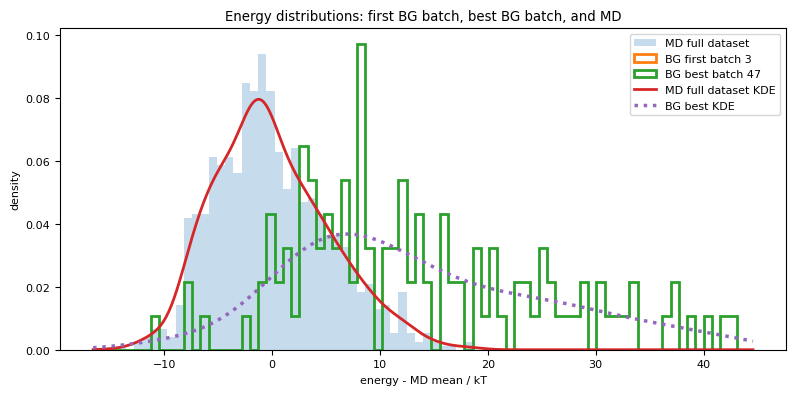


Summary statistics, unshifted energies
--------------------------------------
MD full dataset      mean = -166861.815352 kT, std =  5.327906 kT, min = -166875.848939 kT, max = -166843.438157 kT
BG first             mean =  1625696.795565 kT, std =  15350733.373096 kT, min = -582815.295664 kT, max =  216349408.848634 kT
BG best              mean = -165659.977867 kT, std =  15135.183838 kT, min = -166872.921413 kT, max =  47684.341846 kT


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ============================================================
# User controls
# ============================================================

crystal_index = 0

n_bins = 80

# Use None for all BG samples, or e.g. 1000 if PES evaluation is slow
max_samples_per_batch = None

# MD distribution:
# "full" = all MD energies in _nn.u
# "validation_best" = validation energies saved in the best BAR batch
md_source = "full"

# Plotting convention
plot_shifted = True      # True = subtract MD mean for readability
energy_range = None      # e.g. [-120, 40] if shifted, or [-166950, -166750] if unshifted

# Optional clipping for pathological high-energy BG structures
use_percentile_range = True
percentile_range = [0.5, 80]

# KDE controls
plot_kde = True
kde_points = 500
kde_bw_method = None   # None = scipy default; try 0.2, 0.3, 'scott', 'silverman'

# ============================================================
# Load diagnostics if needed
# ============================================================

_nn = nn.nns[crystal_index]

if not hasattr(_nn, "estimates"):
    nn.load_misc_()

# ============================================================
# Find first saved batch and best AVMD_V batch
# ============================================================

AVMD_V = np.asarray(_nn.estimates[0, :, 1], dtype=float)
valid = np.isfinite(AVMD_V) & (AVMD_V > -1e19)
idx_valid = np.where(valid)[0]

if len(idx_valid) == 0:
    raise RuntimeError("No valid AVMD_V entries found.")

idx_first = idx_valid[0]
idx_best = idx_valid[np.argmax(AVMD_V[valid])]

print("First saved batch")
print("-----------------")
print("estimate index :", idx_first)
print("training batch :", _nn.evaluation_grid[idx_first])
print("AVMD_V         :", AVMD_V[idx_first])

print()
print("Best AVMD_V batch")
print("-----------------")
print("estimate index :", idx_best)
print("training batch :", _nn.evaluation_grid[idx_best])
print("AVMD_V         :", AVMD_V[idx_best])

# ============================================================
# Helper: load BG samples and compute energies
# ============================================================

def load_BG_energy_for_estimate(_nn, estimate_index, crystal_index=0, max_samples=None):
    path_and_name = (
        _nn.name_save_BAR_inputs
        + "_BAR_input_"
        + str(estimate_index)
        + "_state"
        + str(crystal_index)
        + "_"
    )

    name_samples = path_and_name + "_r_&_ln(q(r))"

    print()
    print("Loading:")
    print(name_samples)

    r_BG, ln_q_BG, u_V, ln_q_V, w_V = load_pickle_(name_samples)

    if max_samples is not None:
        r_BG = r_BG[:max_samples]
        u_V = u_V[:max_samples]

    print("Evaluating BG energies...")
    u_BG = _nn.u_(r_BG).reshape(-1)
    u_V = np.asarray(u_V).reshape(-1)

    print("n_BG:", len(u_BG))
    print("BG range / kT:", float(u_BG.min()), float(u_BG.max()))
    print("MD_V range / kT:", float(u_V.min()), float(u_V.max()))

    return u_BG, u_V

# ============================================================
# Compute distributions
# ============================================================

u_BG_first, u_V_first = load_BG_energy_for_estimate(
    _nn,
    idx_first,
    crystal_index=crystal_index,
    max_samples=max_samples_per_batch,
)

u_BG_best, u_V_best = load_BG_energy_for_estimate(
    _nn,
    idx_best,
    crystal_index=crystal_index,
    max_samples=max_samples_per_batch,
)

if md_source == "full":
    u_MD = np.asarray(_nn.u).reshape(-1)
    md_label = "MD full dataset"
elif md_source == "validation_best":
    u_MD = u_V_best
    md_label = "MD validation batch"
else:
    raise ValueError("md_source must be 'full' or 'validation_best'")

print()
print("MD source:", md_label)
print("n_MD:", len(u_MD))
print("MD range / kT:", float(u_MD.min()), float(u_MD.max()))

# ============================================================
# Shift/reference
# ============================================================

if plot_shifted:
    u_ref = float(np.mean(u_MD))
else:
    u_ref = 0.0

u_MD_plot = u_MD - u_ref
u_BG_first_plot = u_BG_first - u_ref
u_BG_best_plot = u_BG_best - u_ref

print()
print("Energy reference / kT:", u_ref)

# ============================================================
# Choose plot range
# ============================================================

if energy_range is not None:
    plot_range = energy_range
elif use_percentile_range:
    all_e = np.concatenate([u_MD_plot, u_BG_first_plot, u_BG_best_plot])
    lo, hi = np.percentile(all_e, percentile_range)
    pad = 0.10 * (hi - lo)
    plot_range = [lo - pad, hi + pad]
else:
    plot_range = None

print("Plot range:", plot_range)

# ============================================================
# Apply range filtering for plotting/KDE
# ============================================================

def filter_range(values, plot_range):
    values = np.asarray(values).reshape(-1)
    if plot_range is None:
        return values
    mask = (values >= plot_range[0]) & (values <= plot_range[1])
    return values[mask]

u_MD_plot_f = filter_range(u_MD_plot, plot_range)
u_BG_first_plot_f = filter_range(u_BG_first_plot, plot_range)
u_BG_best_plot_f = filter_range(u_BG_best_plot, plot_range)

# ============================================================
# Plot histograms
# ============================================================

plt.figure(figsize=(8, 4))

plt.hist(
    u_MD_plot_f,
    bins=n_bins,
    range=plot_range,
    density=True,
    histtype="stepfilled",
    alpha=0.25,
    label=md_label,
)

plt.hist(
    u_BG_first_plot_f,
    bins=n_bins,
    range=plot_range,
    density=True,
    histtype="step",
    linewidth=2,
    label=f"BG first batch {_nn.evaluation_grid[idx_first]}",
)

plt.hist(
    u_BG_best_plot_f,
    bins=n_bins,
    range=plot_range,
    density=True,
    histtype="step",
    linewidth=2,
    label=f"BG best batch {_nn.evaluation_grid[idx_best]}",
)

# ============================================================
# Overlay KDE
# ============================================================

if plot_kde:
    if plot_range is None:
        xmin = min(u_MD_plot_f.min(), u_BG_first_plot_f.min(), u_BG_best_plot_f.min())
        xmax = max(u_MD_plot_f.max(), u_BG_first_plot_f.max(), u_BG_best_plot_f.max())
    else:
        xmin, xmax = plot_range

    xgrid = np.linspace(xmin, xmax, kde_points)

    def add_kde(values, label=None, linestyle="-", linewidth=2):
        values = np.asarray(values).reshape(-1)
        if len(values) < 2:
            return
        kde = gaussian_kde(values, bw_method=kde_bw_method)
        plt.plot(xgrid, kde(xgrid), linestyle=linestyle, linewidth=linewidth, label=label)

    add_kde(u_MD_plot_f, label=f"{md_label} KDE", linestyle="-", linewidth=2)
    add_kde(u_BG_first_plot_f, label="BG first KDE", linestyle="--", linewidth=2)
    add_kde(u_BG_best_plot_f, label="BG best KDE", linestyle=":", linewidth=2.5)

if plot_shifted:
    plt.xlabel("energy - MD mean / kT")
else:
    plt.xlabel("energy / kT")

plt.ylabel("density")
plt.title("Energy distributions: first BG batch, best BG batch, and MD")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Print summary statistics
# ============================================================

def print_stats(name, values):
    values = np.asarray(values).reshape(-1)
    print(
        f"{name:20s}"
        f" mean = {values.mean(): .6f} kT,"
        f" std = {values.std(ddof=1): .6f} kT,"
        f" min = {values.min(): .6f} kT,"
        f" max = {values.max(): .6f} kT"
    )

print()
print("Summary statistics, unshifted energies")
print("--------------------------------------")
print_stats(md_label, u_MD)
print_stats("BG first", u_BG_first)
print_stats("BG best", u_BG_best)